### Постановка задачи

Нужно решить следующую **жесткую** систему:

$$\begin{cases}
\dfrac{dF_1}{dt} = k_1 - \left(\dfrac{k_2F_6}{F_6 + c_2} + \dfrac{k_3F_5}{F_5+c_3} + \dfrac{k_4F_4}{F_4+c_4}\right)F_1 - d_1F_1, \\
\dfrac{dF_2}{dt} = \left(\dfrac{k_2F_6}{F_6+c_2} + \dfrac{k_3F_5}{F_5 + c_3}\right)F_1 + k_5F_3 - k_6F_2 - d_1F_2, \\
\dfrac{dF_3}{dt} = k_4F_1\dfrac{F_4}{F_4 + c_4} + k_6F_2 - k_5F_3 - d_1F_3, \\
\dfrac{dF_4}{dt} = \lambda_3 F_3 \dfrac{c_1}{c_1 + F_4} - d_2F_4, \\
\dfrac{dF_5}{dt} = \lambda_1F_2 \dfrac{c_5}{c_5 + F_4} - d_3F_5, \\
\dfrac{dF_6}{dt} = \lambda_2F_2 \dfrac{c_5}{c_5 + F_4} - d_4F_6.
\end{cases}$$

Начальное условие:

$$\vec F(0)=(0.05,\;0.005,\;0.005,\;0.16,\;0.785,\;0.01).$$

Будем использовать: методы степенных рядов, неявный и модифицированный Эйлер, центральные разности, методы Адамса и метод Гира. Отдельно добавим разностные схемы с весом $\sigma$.


In [1]:
import math
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from numpy.linalg import eigvals, norm

np.set_printoptions(precision=6, suppress=True)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.grid"] = True

Зададим параметры, начальную точку и отрезок интегрировании. Начальная точка у нас задана явно через $k_n$, в то время как отрезок не задан, поэтому введет для него переменную `b` так, чтобы можно было работать на отрезке [0, b].

In [2]:
params = {
    "k1": 1.0,
    "k2": 0.1,
    "k3": 1.0,
    "k4": 0.3,
    "k5": 0.05,
    "k6": 0.075,
    "d1": 0.2,
    "d2": 2.5,
    "d3": 55.0,
    "d4": 10.5,
    "c1": 100.0,
    "c2": 10.0,
    "c3": 10.0,
    "c4": 5.0,
    "c5": 25.0,
    "lambda1": 7e-4,
    "lambda2": 5e-4,
    "lambda3": 5e-4,
}

In [3]:
Y0 = np.array([0.05, 0.005, 0.005, 0.16, 0.785, 0.01], dtype=float)
a = 0.0
b = 1.0


N_values = [32, 64, 128, 256, 512, 1024, 2048, 4096]
N_ref = 4096 * 8 #для эталонного значения выберем очень маленьку сетку.

In [4]:
param_table = pd.DataFrame(
    [params],
    columns=["k1", "k2", "k3", "k4", "k5", "k6", "d1", "d2", "d3", "d4", "c1", "c2", "c3", "c4", "c5", "lambda1", "lambda2", "lambda3"],
).T.rename(columns={0: "value"})

display(param_table)

,value
k1,1.0000
k2,0.1000
k3,1.0000
k4,0.3000
k5,0.0500
k6,0.0750
d1,0.2000
d2,2.5000
d3,55.0000
d4,10.5000


Введем, как и в предыдущей лабораторной работе, функцию построения сетки.

In [5]:
def grid(a, b, N):
    h = (b - a) / N
    grid = np.array([a + i * h for i in range(N + 1)], dtype=float)
    return grid, h

Пусть система у нас и **автономная** (не зависящая явно от $t$), параметр $t$ в функциях оставим для красоты.

In [6]:
def F_system(t, Y):
    F1, F2, F3, F4, F5, F6 = np.asarray(Y, dtype=float)
    p = params

    term_26 = p["k2"] * F6 / (F6 + p["c2"])
    term_35 = p["k3"] * F5 / (F5 + p["c3"])
    term_44 = p["k4"] * F4 / (F4 + p["c4"])
    immune_den = p["c5"] + F4

    return np.array([
        p["k1"] - (term_26 + term_35 + term_44) * F1 - p["d1"] * F1,
        (term_26 + term_35) * F1 + p["k5"] * F3 - p["k6"] * F2 - p["d1"] * F2,
        term_44 * F1 + p["k6"] * F2 - p["k5"] * F3 - p["d1"] * F3,
        p["lambda3"] * F3 * p["c1"] / (p["c1"] + F4) - p["d2"] * F4,
        p["lambda1"] * F2 * p["c5"] / immune_den - p["d3"] * F5,
        p["lambda2"] * F2 * p["c5"] / immune_den - p["d4"] * F6,
    ], dtype=float)


In [7]:
def numerical_jacobian(F, t, Y, eps=1e-7):
    Y = np.asarray(Y, dtype=float)
    n = len(Y)
    J = np.zeros((n, n), dtype=float)

    for i in range(n):
        step = eps * max(1.0, abs(Y[i]))
        e = np.zeros(n, dtype=float)
        e[i] = step
        J[:, i] = (F(t, Y + e) - F(t, Y - e)) / (2.0 * step)

    return J


def max_norm(values):
    return norm(values, ord=np.inf)

Определим сперва жесткость нашей системы.  

Известно, что если собственные числа матрицы Якоби $\lambda_1, ... , \lambda_k$ отрицательные: $\lambda_k < 0$ и число $S^{*} = \sup_{t \in [t_0, T]} S(t)$ **"достаточно велико"**.  

Где $$S(t) = \frac{\max|Re \lambda_i(t)|}{\min|Re \lambda_i(t)|}$$

In [8]:
J0 = numerical_jacobian(F_system, a, Y0)
eig0 = eigvals(J0)
negative_re = [abs(z.real) for z in eig0 if z.real < -1e-12]
stiffness_number = max(negative_re) / min(negative_re)

In [9]:
eigen_table = pd.DataFrame({
    "eigenvalue": eig0,
    "Re": np.real(eig0),
    "Im": np.imag(eig0),
    "abs_Re": np.abs(np.real(eig0)),
}).sort_values("abs_Re", ascending=False)

In [10]:
display(eigen_table)
print(f"Число жесткости в начальной точке примерно S = {stiffness_number:.2f}")

,eigenvalue,Re,Im,abs_Re
0,-55.000000,-55.000000,0.0,55.000000
4,-10.500000,-10.500000,0.0,10.500000
5,-2.500001,-2.500001,0.0,2.500001
3,-0.325000,-0.325000,0.0,0.325000
2,-0.282188,-0.282188,0.0,0.282188
1,-0.200000,-0.200000,0.0,0.200000


Число жесткости в начальной точке примерно S = 275.00


В этой задаче мы не имеем аналитичного решения, поэтому погрешность мы сможем считать с помощью метода Рунге и эталонного решения.

In [11]:
def inaccuracy_system(reference_values, numerical_values, stride=1):
    if numerical_values is None:
        return np.inf

    max_error = 0.0
    for i, y_num in enumerate(numerical_values):
        if i * stride >= len(reference_values):
            return np.inf
        y_ref = reference_values[i * stride]
        if not np.all(np.isfinite(y_num)):
            return np.inf
        max_error = max(max_error, norm(y_ref - y_num, ord=np.inf))

    return max_error

In [12]:
def runge_estimate_system(solution_coarse, solution_fine, p):
    if solution_coarse is None or solution_fine is None:
        return np.nan

    max_diff = 0.0
    for i, y_coarse in enumerate(solution_coarse):
        y_fine = solution_fine[2 * i]
        if not np.all(np.isfinite(y_coarse)) or not np.all(np.isfinite(y_fine)):
            return np.nan
        max_diff = max(max_diff, norm(y_fine - y_coarse, ord=np.inf))

    return max_diff / (2**p - 1)


In [13]:
def experimental_orders(errors):
    p = [np.nan]
    for i in range(1, len(errors)):
        e_prev = errors[i - 1]
        e_curr = errors[i]
        if e_prev == 0 or e_curr == 0 or not np.isfinite(e_prev) or not np.isfinite(e_curr):
            p.append(np.nan)
        else:
            p.append(np.log2(e_prev / e_curr))
    return p

К сожалению, нам придется решать нелинейные системы на каждом шаге. Раньше мы могли выразить это явно через формулу. Теперь это не выйдет.

In [14]:
def newton_solve(residual, x0, tol=1e-11, max_iter=30):
    x = np.asarray(x0, dtype=float).copy()

    for iteration in range(1, max_iter + 1):
        r = residual(x)

        if norm(r, ord=np.inf) < tol:
            return x, {"iterations": iteration - 1, "converged": True}

        def residual_as_function(t, z):
            return residual(z)

        J = numerical_jacobian(residual_as_function, 0.0, x)
        delta = np.linalg.solve(J, -r)

        x = x + delta

        if norm(delta, ord=np.inf) < tol * (1 + norm(x, ord=np.inf)):
            return x, {"iterations": iteration, "converged": True}

    return x, {"iterations": max_iter, "converged": False}


Добавим функцию проверки для каждого метода - если у нас метод выдал inf, -inf или nan, значит метод численно сломался. Делаем выводы.

In [15]:
def step_failed(Y):
    return (not np.all(np.isfinite(Y))) or norm(Y, ord=np.inf) > 1e8

### Методы степенных рядов и методы Эйлера:  

Для автономной системы:  
$$Y' = F(Y)$$
$$Y'' = J(Y)F(Y)$$
Тогда третья производная - направденная производная от $Y''$ вдоль $F(Y)$

In [16]:
def directional_derivative(func, Y, direction):
    direction = np.asarray(direction, dtype=float)
    d_norm = norm(direction, ord=np.inf)
    if d_norm == 0 or not np.isfinite(d_norm):
        return np.zeros_like(direction)

    eps = 1e-5 / max(1.0, d_norm)
    return (func(Y + eps * direction) - func(Y - eps * direction)) / (2.0 * eps)


def system_second_derivative(t, Y, F):
    FY = F(t, Y)
    J = numerical_jacobian(F, t, Y)
    return J @ FY


def system_third_derivative(t, Y, F):
    FY = F(t, Y)

    def y2_at(Z):
        return numerical_jacobian(F, t, Z) @ F(t, Z)

    return directional_derivative(y2_at, np.asarray(Y, dtype=float), FY)


def power_series_method_1(t, Y, h, F):
    return Y + h * F(t, Y), {"newton_iterations": 0, "newton_failed": 0}


def power_series_method_2(t, Y, h, F):
    F0 = F(t, Y)
    Y2 = system_second_derivative(t, Y, F)
    return Y + h * F0 + h**2 / 2.0 * Y2, {"newton_iterations": 0, "newton_failed": 0}


def power_series_method_3(t, Y, h, F):
    F0 = F(t, Y)
    Y2 = system_second_derivative(t, Y, F)
    Y3 = system_third_derivative(t, Y, F)
    return Y + h * F0 + h**2 / 2.0 * Y2 + h**3 / 6.0 * Y3, {"newton_iterations": 0, "newton_failed": 0}


def implicit_method(t, Y, h, F):
    Y_pred = Y + h * F(t, Y)

    def residual(Z):
        return Z - Y - h * F(t + h, Z)

    Y_next, info = newton_solve(residual, Y_pred)
    return Y_next, {"newton_iterations": info["iterations"], "newton_failed": int(not info["converged"])}


def modified_euler(t, Y, h, F):
    Y_pred = Y + h * F(t, Y)
    Y_next = Y + h / 2.0 * (F(t, Y) + F(t + h, Y_pred))
    return Y_next, {"newton_iterations": 0, "newton_failed": 0}


### Разностные схемы:  

Для задачи Коши:  
$$\frac{Y_{j+1} - Y_j}{h} = (1 - \sigma)F(t_j, Y_j) + \sigma F(t_{j+1}, Y_{j+1})$$

При $\sigma$ = 0 - явная схема Эйлера  
При $\sigma$ = 1 - неявная схема Эйлера  

In [17]:
def weighted_difference_method(t, Y, h, F, sigma):
    if sigma == 0:
        return Y + h * F(t, Y), {"newton_iterations": 0, "newton_failed": 0}

    Y_pred = Y + h * F(t, Y)
    F_current = F(t, Y)

    def residual(Z):
        return Z - Y - h * ((1.0 - sigma) * F_current + sigma * F(t + h, Z))

    Y_next, info = newton_solve(residual, Y_pred)
    return Y_next, {"newton_iterations": info["iterations"], "newton_failed": int(not info["converged"])}


def central_difference_method(t, Y_prev, Y_current, h, F):
    return Y_prev + 2.0 * h * F(t, Y_current), {"newton_iterations": 0, "newton_failed": 0}


### Многошаговые методы Адамса и Гира  
Методы: АБ, АМ, АБМ, метод Гира.  

Неявны  формулы решаются методом Ньютона.  

Стартовое значение берем методом степенного ряда третьего порядка.

In [18]:
def adams_explicit_2_system(t_j, Y_j, Y_jm1, h, F):
    F_j = F(t_j, Y_j)
    F_jm1 = F(t_j - h, Y_jm1)
    return Y_j + h / 2.0 * (3.0 * F_j - F_jm1), {"newton_iterations": 0, "newton_failed": 0}


def adams_implicit_2_system(t_j, Y_j, Y_jm1, h, F):
    F_j = F(t_j, Y_j)
    F_jm1 = F(t_j - h, Y_jm1)
    Y_pred = Y_j + h / 2.0 * (3.0 * F_j - F_jm1)

    def residual(Z):
        return Z - Y_j - h / 12.0 * (5.0 * F(t_j + h, Z) + 8.0 * F_j - F_jm1)

    Y_next, info = newton_solve(residual, Y_pred)
    return Y_next, {"newton_iterations": info["iterations"], "newton_failed": int(not info["converged"])}


def adams_predictor_corrector_system(t_j, Y_j, Y_jm1, Y_jm2, Y_jm3, h, F):
    F_j = F(t_j, Y_j)
    F_jm1 = F(t_j - h, Y_jm1)
    F_jm2 = F(t_j - 2.0 * h, Y_jm2)
    F_jm3 = F(t_j - 3.0 * h, Y_jm3)

    Y_pred = Y_j + h / 24.0 * (55.0 * F_j - 59.0 * F_jm1 + 37.0 * F_jm2 - 9.0 * F_jm3)

    def residual(Z):
        return Z - Y_j - h / 24.0 * (9.0 * F(t_j + h, Z) + 19.0 * F_j - 5.0 * F_jm1 + F_jm2)

    Y_next, info = newton_solve(residual, Y_pred)
    return Y_next, {"newton_iterations": info["iterations"], "newton_failed": int(not info["converged"])}


def gear_method_3_system(t_j, Y_j, Y_jm1, Y_jm2, h, F):
    Y_pred = Y_j + (Y_j - Y_jm1)

    def residual(Z):
        return 11.0 * Z - 18.0 * Y_j + 9.0 * Y_jm1 - 2.0 * Y_jm2 - 6.0 * h * F(t_j + h, Z)

    Y_next, info = newton_solve(residual, Y_pred)
    return Y_next, {"newton_iterations": info["iterations"], "newton_failed": int(not info["converged"])}


In [19]:
def starting_values_by_taylor3(domain, h, count):
    values = [Y0.copy()]
    stats = {"newton_iterations": 0, "newton_failed": 0}

    for k in range(count):
        Y_next, info = power_series_method_3(domain[k], values[-1], h, F_system)
        values.append(Y_next)
        stats["newton_iterations"] += info.get("newton_iterations", 0)
        stats["newton_failed"] += info.get("newton_failed", 0)

    return values, stats


methods_meta = {
    "ps1": {"title": "Степенной ряд 1 / явный Эйлер", "order": 1, "stability": "euler_explicit"},
    "ps2": {"title": "Степенной ряд 2", "order": 2, "stability": "taylor2"},
    "ps3": {"title": "Степенной ряд 3", "order": 3, "stability": "taylor3"},
    "implicit_euler": {"title": "Неявный Эйлер", "order": 1, "stability": "euler_implicit"},
    "modified_euler": {"title": "Модифицированный Эйлер", "order": 2, "stability": "taylor2"},
    "central_difference": {"title": "Центральные разности", "order": 2, "stability": "central"},
    "diff_sigma_0": {"title": "Разностная схема, sigma=0", "order": 1, "stability": "weighted_0"},
    "diff_sigma_05": {"title": "Разностная схема, sigma=1/2", "order": 2, "stability": "weighted_05"},
    "diff_sigma_1": {"title": "Разностная схема, sigma=1", "order": 1, "stability": "weighted_1"},
    "adams_explicit_2": {"title": "Адамс-Бэшфорт 2", "order": 2, "stability": "ab2"},
    "adams_implicit_2": {"title": "Адамс-Моултон 2", "order": 3, "stability": "am2"},
    "adams_pc": {"title": "Адамс-Бэшфорт-Моултон 4", "order": 4, "stability": "am4"},
    "gear_3": {"title": "Гир / BDF3", "order": 3, "stability": "bdf3"},
}

method_order = list(methods_meta.keys())


In [20]:
def solve_one_method(method_name, N):
    domain, h = grid(a, b, N)
    stats = {
        "h": h,
        "steps": N,
        "newton_iterations": 0,
        "newton_failed": 0,
        "failed": False,
        "elapsed": 0.0,
    }

    start_time = time.perf_counter()

    try:
        if method_name in ["ps1", "ps2", "ps3", "implicit_euler", "modified_euler", "diff_sigma_0", "diff_sigma_05", "diff_sigma_1"]:
            values = [Y0.copy()]

            for j in range(N):
                t_j = domain[j]
                Y_j = values[-1]

                if method_name == "ps1":
                    Y_next, info = power_series_method_1(t_j, Y_j, h, F_system)
                elif method_name == "ps2":
                    Y_next, info = power_series_method_2(t_j, Y_j, h, F_system)
                elif method_name == "ps3":
                    Y_next, info = power_series_method_3(t_j, Y_j, h, F_system)
                elif method_name == "implicit_euler":
                    Y_next, info = implicit_method(t_j, Y_j, h, F_system)
                elif method_name == "modified_euler":
                    Y_next, info = modified_euler(t_j, Y_j, h, F_system)
                elif method_name == "diff_sigma_0":
                    Y_next, info = weighted_difference_method(t_j, Y_j, h, F_system, sigma=0.0)
                elif method_name == "diff_sigma_05":
                    Y_next, info = weighted_difference_method(t_j, Y_j, h, F_system, sigma=0.5)
                elif method_name == "diff_sigma_1":
                    Y_next, info = weighted_difference_method(t_j, Y_j, h, F_system, sigma=1.0)

                stats["newton_iterations"] += info.get("newton_iterations", 0)
                stats["newton_failed"] += info.get("newton_failed", 0)

                if step_failed(Y_next):
                    stats["failed"] = True
                    break

                values.append(Y_next)

        elif method_name == "central_difference":
            values, start_stats = starting_values_by_taylor3(domain, h, count=1)
            stats["newton_iterations"] += start_stats["newton_iterations"]
            stats["newton_failed"] += start_stats["newton_failed"]

            for j in range(1, N):
                Y_next, info = central_difference_method(domain[j], values[j - 1], values[j], h, F_system)
                if step_failed(Y_next):
                    stats["failed"] = True
                    break
                values.append(Y_next)

        elif method_name in ["adams_explicit_2", "adams_implicit_2"]:
            values, start_stats = starting_values_by_taylor3(domain, h, count=1)
            stats["newton_iterations"] += start_stats["newton_iterations"]
            stats["newton_failed"] += start_stats["newton_failed"]

            for j in range(1, N):
                if method_name == "adams_explicit_2":
                    Y_next, info = adams_explicit_2_system(domain[j], values[j], values[j - 1], h, F_system)
                else:
                    Y_next, info = adams_implicit_2_system(domain[j], values[j], values[j - 1], h, F_system)

                stats["newton_iterations"] += info.get("newton_iterations", 0)
                stats["newton_failed"] += info.get("newton_failed", 0)

                if step_failed(Y_next):
                    stats["failed"] = True
                    break
                values.append(Y_next)

        elif method_name == "adams_pc":
            values, start_stats = starting_values_by_taylor3(domain, h, count=3)
            stats["newton_iterations"] += start_stats["newton_iterations"]
            stats["newton_failed"] += start_stats["newton_failed"]

            for j in range(3, N):
                Y_next, info = adams_predictor_corrector_system(domain[j], values[j], values[j - 1], values[j - 2], values[j - 3], h, F_system)
                stats["newton_iterations"] += info.get("newton_iterations", 0)
                stats["newton_failed"] += info.get("newton_failed", 0)

                if step_failed(Y_next):
                    stats["failed"] = True
                    break
                values.append(Y_next)

        elif method_name == "gear_3":
            values, start_stats = starting_values_by_taylor3(domain, h, count=2)
            stats["newton_iterations"] += start_stats["newton_iterations"]
            stats["newton_failed"] += start_stats["newton_failed"]

            for j in range(2, N):
                Y_next, info = gear_method_3_system(domain[j], values[j], values[j - 1], values[j - 2], h, F_system)
                stats["newton_iterations"] += info.get("newton_iterations", 0)
                stats["newton_failed"] += info.get("newton_failed", 0)

                if step_failed(Y_next):
                    stats["failed"] = True
                    break
                values.append(Y_next)

        else:
            raise ValueError(f"Unknown method: {method_name}")

    except Exception as exc:
        values = None
        stats["failed"] = True
        stats["error"] = repr(exc)

    stats["elapsed"] = time.perf_counter() - start_time

    if values is not None and len(values) != N + 1:
        stats["failed"] = True
        values = None

    return domain, values, stats


Построим эталонное решени с помощью метода Гира на эталонной сетке.  

In [21]:
ref_domain, ref_values, ref_stats = solve_one_method("gear_3", N_ref)
print("Эталонное решение построено методом Гира")
print(f"N_ref = {N_ref}, h_ref = {(b - a) / N_ref:.6g}, failed = {ref_stats['failed']}, time = {ref_stats['elapsed']:.3f} sec")
print("Y_ref(b) =", ref_values[-1])


Эталонное решение построено методом Гира
N_ref = 32768, h_ref = 3.05176e-05, failed = False, time = 11.408 sec
Y_ref(b) = [0.94613  0.004097 0.005244 0.013135 0.       0.      ]


Теперь решим задачу всеми методами на последовательности сеток. Для каждого метода получим ошибку **относительно эталона**, оценку Рунге, эксперементальные порядки и время выполнения.

In [22]:
solutions = {method: {} for method in method_order}
raw_stats = []

for method in method_order:
    for N in N_values:
        domain, values, stats = solve_one_method(method, N)
        solutions[method][N] = {"domain": domain, "values": values, "stats": stats}
        raw_stats.append({
            "method": method,
            "title": methods_meta[method]["title"],
            "N": N,
            "h": stats["h"],
            "failed": stats["failed"],
            "newton_iterations": stats["newton_iterations"],
            "newton_failed": stats["newton_failed"],
            "elapsed": stats["elapsed"],
        })

raw_stats_df = pd.DataFrame(raw_stats)

In [23]:
display(raw_stats_df.head(20))

,method,title,N,h,failed,newton_iterations,newton_failed,elapsed
0,ps1,Степенной ряд 1 / явный Эйлер,32,0.031250,False,0,0,0.001328
1,ps1,Степенной ряд 1 / явный Эйлер,64,0.015625,False,0,0,0.002714
2,ps1,Степенной ряд 1 / явный Эйлер,128,0.007812,False,0,0,0.004530
3,ps1,Степенной ряд 1 / явный Эйлер,256,0.003906,False,0,0,0.007727
4,ps1,Степенной ряд 1 / явный Эйлер,512,0.001953,False,0,0,0.012663
5,ps1,Степенной ряд 1 / явный Эйлер,1024,0.000977,False,0,0,0.022389
6,ps1,Степенной ряд 1 / явный Эйлер,2048,0.000488,False,0,0,0.041399
7,ps1,Степенной ряд 1 / явный Эйлер,4096,0.000244,False,0,0,0.074290
8,ps2,Степенной ряд 2,32,0.031250,False,0,0,0.004354
9,ps2,Степенной ряд 2,64,0.015625,False,0,0,0.009905


In [24]:
def build_method_table(method):
    p_method = methods_meta[method]["order"]
    eps_ref = []
    eps_runge = [np.nan]
    h_values = []
    elapsed = []
    failed = []

    for i, N in enumerate(N_values):
        values = solutions[method][N]["values"]
        stats = solutions[method][N]["stats"]
        stride_ref = N_ref // N
        eps_ref.append(inaccuracy_system(ref_values, values, stride=stride_ref))
        h_values.append(stats["h"])
        elapsed.append(stats["elapsed"])
        failed.append(stats["failed"])

        if i > 0:
            N_prev = N_values[i - 1]
            values_prev = solutions[method][N_prev]["values"]
            values_curr = solutions[method][N]["values"]
            eps_runge.append(runge_estimate_system(values_prev, values_curr, p_method))

    table = pd.DataFrame({
        "N": N_values,
        "h": h_values,
        "eps_ref": eps_ref,
        "eps_runge": eps_runge,
        "p_ref": experimental_orders(eps_ref),
        "p_runge": experimental_orders(eps_runge),
        "time_sec": elapsed,
        "failed": failed,
    })

    return table

method_tables = {method: build_method_table(method) for method in method_order}

summary_eps = pd.DataFrame({"N": N_values, "h": [(b - a) / N for N in N_values]})
summary_p = pd.DataFrame({"N": N_values})

for method in method_order:
    title = methods_meta[method]["title"]
    summary_eps[title] = method_tables[method]["eps_ref"]
    summary_p[title] = method_tables[method]["p_ref"]

print("Погрешность относительно эталонного решения")
display(summary_eps)
print("Экспериментальные порядки")
display(summary_p)


Погрешность относительно эталонного решения


,N,h,Степенной ряд 1 / явный Эйлер,Степенной ряд 2,Степенной ряд 3,Неявный Эйлер,Модифицированный Эйлер,Центральные разности,"Разностная схема, sigma=0","Разностная схема, sigma=1/2","Разностная схема, sigma=1",Адамс-Бэшфорт 2,Адамс-Моултон 2,Адамс-Бэшфорт-Моултон 4,Гир / BDF3
0,32,0.031250,0.704961,0.454523,2.097648e-01,0.147993,0.454523,inf,0.704961,0.081373,0.147993,inf,2.097648e-01,2.097648e-01,2.097648e-01
1,64,0.015625,0.221999,0.067872,1.516410e-02,0.089795,0.067872,inf,0.221999,0.019248,0.089795,0.104864,1.516410e-02,1.516410e-02,1.516410e-02
2,128,0.007812,0.077064,0.012285,1.333440e-03,0.052335,0.012285,inf,0.077064,0.004490,0.052335,0.017599,1.025629e-03,1.333440e-03,2.919966e-03
3,256,0.003906,0.034062,0.002616,1.413871e-04,0.028538,0.002616,inf,0.034062,0.001113,0.028538,0.005040,8.296629e-05,1.303821e-04,5.065923e-04
4,512,0.001953,0.016251,0.000602,1.624717e-05,0.014841,0.000602,inf,0.016251,0.000278,0.014841,0.001327,1.247208e-05,1.031781e-05,7.474680e-05
5,1024,0.000977,0.007933,0.000145,1.946569e-06,0.007587,0.000145,inf,0.007933,0.000069,0.007587,0.000339,1.705984e-06,7.262162e-07,1.020724e-05
6,2048,0.000488,0.003922,0.000035,2.385083e-07,0.003835,0.000035,inf,0.003922,0.000017,0.003835,0.000086,2.226701e-07,4.817673e-08,1.335325e-06
7,4096,0.000244,0.001950,0.000009,2.979188e-08,0.001928,0.000009,inf,0.001950,0.000004,0.001928,0.000022,2.815770e-08,3.121285e-09,1.704823e-07


Экспериментальные порядки


,N,Степенной ряд 1 / явный Эйлер,Степенной ряд 2,Степенной ряд 3,Неявный Эйлер,Модифицированный Эйлер,Центральные разности,"Разностная схема, sigma=0","Разностная схема, sigma=1/2","Разностная схема, sigma=1",Адамс-Бэшфорт 2,Адамс-Моултон 2,Адамс-Бэшфорт-Моултон 4,Гир / BDF3
0,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,64,1.666989,2.743468,3.790041,0.720821,2.743468,NaN,1.666989,2.079854,0.720821,NaN,3.790041,3.790041,3.790041
2,128,1.526432,2.465938,3.507435,0.778867,2.465938,NaN,1.526432,2.099834,0.778867,2.574913,3.886078,3.507435,2.376636
3,256,1.177892,2.231675,3.237430,0.874898,2.231675,NaN,1.177892,2.011930,0.874898,1.804073,3.627840,3.354336,2.527054
4,512,1.067613,2.118498,3.121390,0.943305,2.118498,NaN,1.067613,2.002233,0.943305,1.925553,2.733823,3.659536,2.760741
5,1024,1.034604,2.058781,3.061183,0.967985,2.058781,NaN,1.034604,2.000862,0.967985,1.966412,2.870026,3.828594,2.872420
6,2048,1.016351,2.029120,3.028822,0.984401,2.029120,NaN,1.016351,2.000043,0.984401,1.983619,2.937625,3.913991,2.934329
7,4096,1.008199,2.014650,3.001048,0.991934,2.014650,NaN,1.008199,2.000000,0.991934,1.992116,2.983306,3.948124,2.969497


In [25]:
for method in methods_meta:
    print(methods_meta[method]["title"])
    display(method_tables[method])

Степенной ряд 1 / явный Эйлер


,N,h,eps_ref,eps_runge,p_ref,p_runge,time_sec,failed
0,32,0.031250,0.704961,NaN,NaN,NaN,0.001328,False
1,64,0.015625,0.221999,0.579742,1.666989,NaN,0.002714,False
2,128,0.007812,0.077064,0.144936,1.526432,2.000000,0.004530,False
3,256,0.003906,0.034062,0.043002,1.177892,1.752944,0.007727,False
4,512,0.001953,0.016251,0.017929,1.067613,1.262135,0.012663,False
5,1024,0.000977,0.007933,0.008318,1.034604,1.107921,0.022389,False
6,2048,0.000488,0.003922,0.004013,1.016351,1.051722,0.041399,False
7,4096,0.000244,0.001950,0.001972,1.008199,1.024874,0.074290,False


Степенной ряд 2


,N,h,eps_ref,eps_runge,p_ref,p_runge,time_sec,failed
0,32,0.031250,0.454523,NaN,NaN,NaN,0.004354,False
1,64,0.015625,0.067872,0.132777,2.743468,NaN,0.009905,False
2,128,0.007812,0.012285,0.018529,2.465938,2.841145,0.019067,False
3,256,0.003906,0.002616,0.003231,2.231675,2.519678,0.038152,False
4,512,0.001953,0.000602,0.000671,2.118498,2.266637,0.072072,False
5,1024,0.000977,0.000145,0.000153,2.058781,2.137527,0.162018,False
6,2048,0.000488,0.000035,0.000036,2.029120,2.068358,0.334503,False
7,4096,0.000244,0.000009,0.000009,2.014650,2.033935,0.680655,False


Степенной ряд 3


...

,N,h,eps_ref,eps_runge,p_ref,p_runge,time_sec,failed
0,32,0.031250,2.097648e-01,NaN,NaN,NaN,0.012514,False
1,64,0.015625,1.516410e-02,3.002535e-02,3.790041,NaN,0.024089,False
2,128,0.007812,1.025629e-03,2.161543e-03,3.886078,3.796047,0.038959,False
3,256,0.003906,8.296629e-05,1.461964e-04,3.627840,3.886082,0.076422,False
4,512,0.001953,1.247208e-05,1.012989e-05,2.733823,3.851218,0.150071,False
5,1024,0.000977,1.705984e-06,1.538593e-06,2.870026,2.718935,0.302697,False
6,2048,0.000488,2.226701e-07,2.119841e-07,2.937625,2.859583,0.604120,False
7,4096,0.000244,2.815770e-08,2.778820e-08,2.983306,2.931412,0.397613,False


Адамс-Бэшфорт-Моултон 4


,N,h,eps_ref,eps_runge,p_ref,p_runge,time_sec,failed
0,32,0.031250,2.097648e-01,NaN,NaN,NaN,0.016744,False
1,64,0.015625,1.516410e-02,1.314773e-02,3.790041,NaN,0.024817,False
2,128,0.007812,1.333440e-03,9.220438e-04,3.507435,3.833835,0.050705,False
3,256,0.003906,1.303821e-04,8.163113e-05,3.354336,3.497644,0.053337,False
4,512,0.001953,1.031781e-05,8.161246e-06,3.659536,3.322258,0.065722,False
5,1024,0.000977,7.262162e-07,6.452965e-07,3.828594,3.660755,0.116255,False
6,2048,0.000488,4.817673e-08,4.539885e-08,3.913991,3.829234,0.207451,False
7,4096,0.000244,3.121285e-09,3.007992e-09,3.948124,3.915783,0.352848,False


Гир / BDF3


,N,h,eps_ref,eps_runge,p_ref,p_runge,time_sec,failed
0,32,0.031250,2.097648e-01,NaN,NaN,NaN,0.021487,False
1,64,0.015625,1.516410e-02,2.817371e-02,3.790041,NaN,0.032947,False
2,128,0.007812,2.919966e-03,2.084754e-03,2.376636,3.756400,0.054363,False
3,256,0.003906,5.065923e-04,3.632336e-04,2.527054,2.520908,0.102977,False
4,512,0.001953,7.474680e-05,6.237527e-05,2.760741,2.541852,0.171290,False
5,1024,0.000977,1.020724e-05,9.231297e-06,2.872420,2.756369,0.340683,False
6,2048,0.000488,1.335325e-06,1.268368e-06,2.934329,2.863560,0.636435,False
7,4096,0.000244,1.704823e-07,1.664204e-07,2.969497,2.930069,1.267992,False


Построим графики погрешности. Если метод неустойчив на грубой сетке, его ошибка будет бесконечной или не попадет на график.


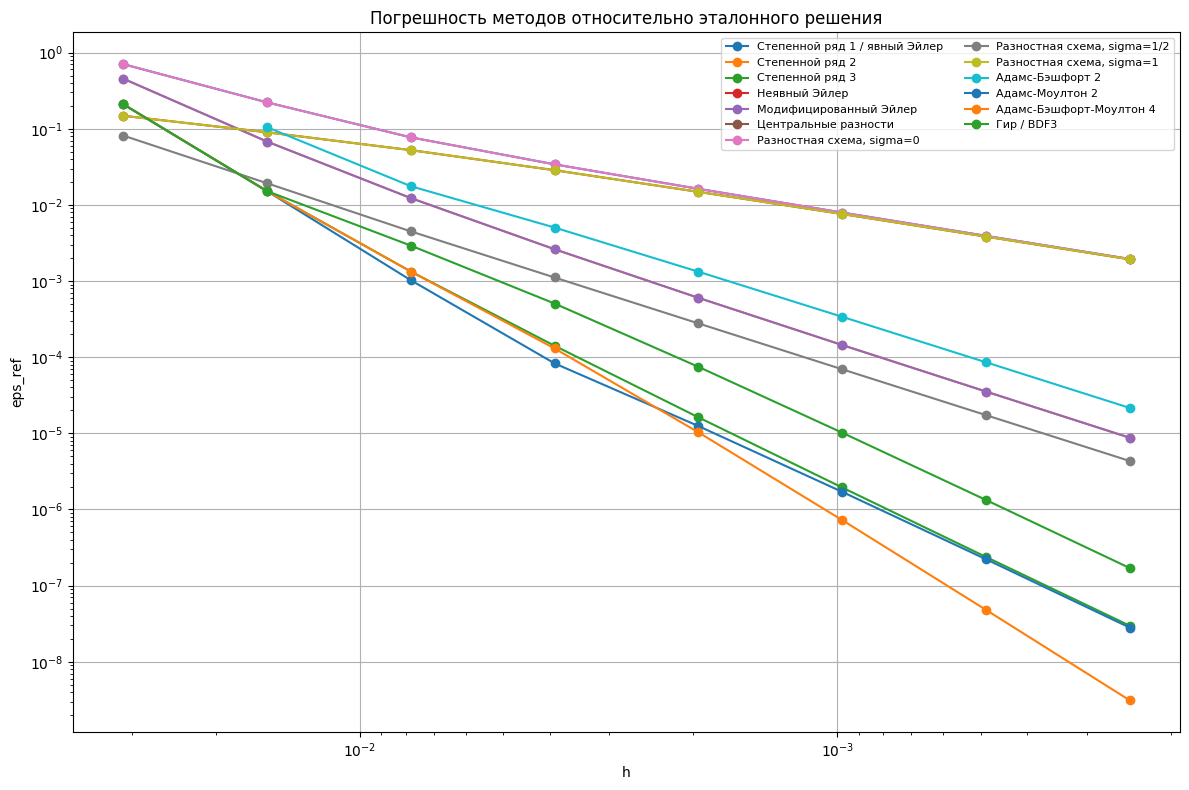

In [26]:
plt.figure(figsize=(12, 8))
for method in method_order:
    table = method_tables[method]
    y = table["eps_ref"].replace([np.inf, -np.inf], np.nan)
    plt.loglog(table["h"], y, marker="o", label=methods_meta[method]["title"])

plt.gca().invert_xaxis()
plt.xlabel("h")
plt.ylabel("eps_ref")
plt.title("Погрешность методов относительно эталонного решения")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


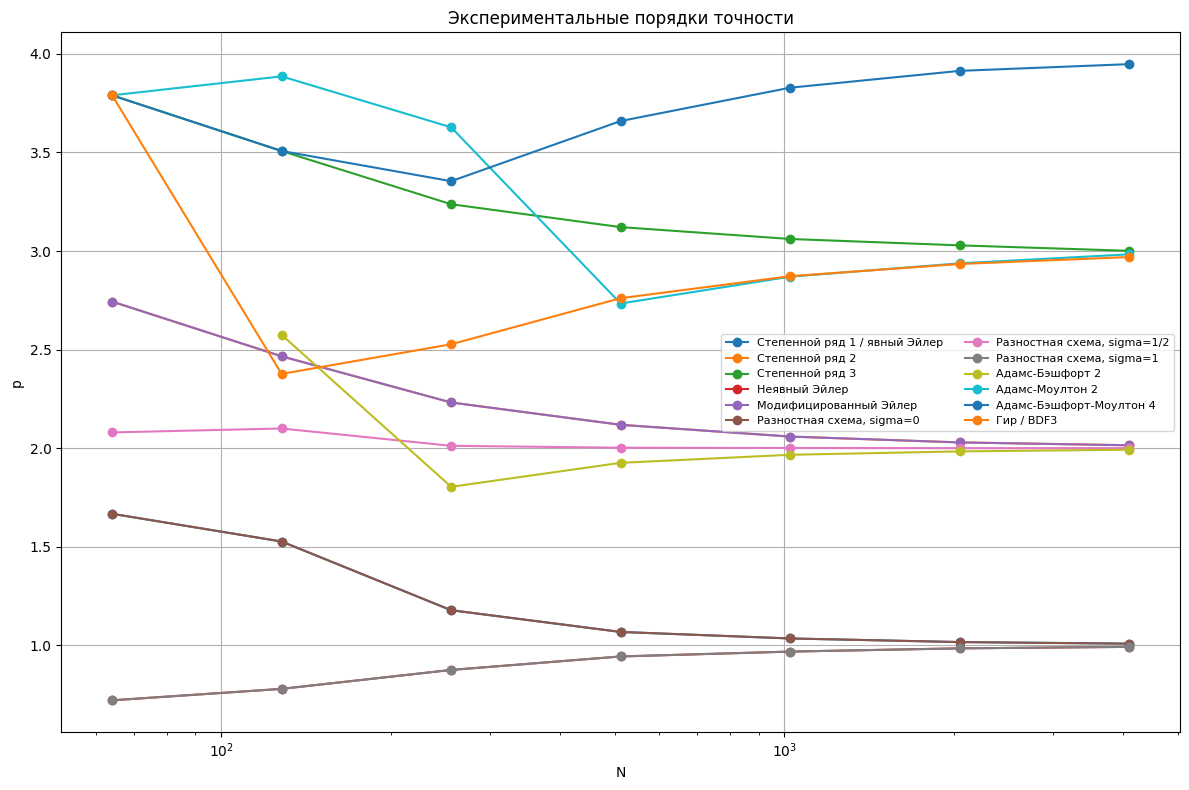

In [27]:
plt.figure(figsize=(12, 8))
for method in method_order:
    table = method_tables[method]
    if table["p_ref"].notna().sum() > 0:
        plt.semilogx(table["N"], table["p_ref"], marker="o", label=methods_meta[method]["title"])

plt.xlabel("N")
plt.ylabel("p")
plt.title("Экспериментальные порядки точности")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


### Области устойчивости

Для исследования устойчивости используем тестовое уравнение $y'=\lambda y$ и обозначение $z=h\lambda$. Метод устойчив в тех точках комплексной плоскости, где все корни соответствующего характеристического уравнения лежат в единичном круге.

Собственные значения Якобиана системы в начальной точке почти действительные и отрицательные, поэтому особенно важна левая часть вещественной оси.


In [28]:
def max_root_abs(coeffs):
    roots = np.roots(coeffs)
    return np.max(np.abs(roots))


def stability_measure(kind, z):
    if kind in ["euler_explicit", "weighted_0"]:
        return abs(1 + z)
    if kind == "taylor2":
        return abs(1 + z + z**2 / 2.0)
    if kind == "taylor3":
        return abs(1 + z + z**2 / 2.0 + z**3 / 6.0)
    if kind in ["euler_implicit", "weighted_1"]:
        return abs(1 / (1 - z))
    if kind == "weighted_05":
        sigma = 0.5
        return abs((1 + (1 - sigma) * z) / (1 - sigma * z))
    if kind == "central":
        return max_root_abs([1, -2 * z, -1])
    if kind == "ab2":
        return max_root_abs([1, -1 - 1.5 * z, 0.5 * z])
    if kind == "am2":
        return max_root_abs([1 - 5 * z / 12.0, -1 - 8 * z / 12.0, z / 12.0])
    if kind == "am4":
        return max_root_abs([1 - 9 * z / 24.0, -1 - 19 * z / 24.0, 5 * z / 24.0, -z / 24.0])
    if kind == "bdf3":
        return max_root_abs([11.0 / 6.0 - z, -3.0, 1.5, -1.0 / 3.0])
    raise ValueError(kind)


def is_stable(kind, z):
    return stability_measure(kind, z) <= 1 + 1e-10


def negative_axis_limit(kind, xmax=80.0, samples=4001):
    xs = np.linspace(0.0, xmax, samples)
    last = 0.0
    for x in xs:
        if is_stable(kind, -x):
            last = x
        else:
            break
    return last

In [29]:
lambda_fast = max(abs(np.real(eig0)))
stability_rows = []
for method in method_order:
    kind = methods_meta[method]["stability"]
    limit = negative_axis_limit(kind)
    h_limit = np.inf if limit >= 79.9 else limit / lambda_fast
    stability_rows.append({
        "method": method,
        "title": methods_meta[method]["title"],
        "stability_kind": kind,
        "x_limit_on_negative_axis": limit if limit < 79.9 else ">= 80",
        "rough_h_limit": h_limit,
    })

stability_df = pd.DataFrame(stability_rows)
display(stability_df)


,method,title,stability_kind,x_limit_on_negative_axis,rough_h_limit
0,ps1,Степенной ряд 1 / явный Эйлер,euler_explicit,2.0,0.036364
1,ps2,Степенной ряд 2,taylor2,2.0,0.036364
2,ps3,Степенной ряд 3,taylor3,2.5,0.045455
3,implicit_euler,Неявный Эйлер,euler_implicit,>= 80,inf
4,modified_euler,Модифицированный Эйлер,taylor2,2.0,0.036364
5,central_difference,Центральные разности,central,0.0,0.000000
6,diff_sigma_0,"Разностная схема, sigma=0",weighted_0,2.0,0.036364
7,diff_sigma_05,"Разностная схема, sigma=1/2",weighted_05,>= 80,inf
8,diff_sigma_1,"Разностная схема, sigma=1",weighted_1,>= 80,inf
9,adams_explicit_2,Адамс-Бэшфорт 2,ab2,1.0,0.018182


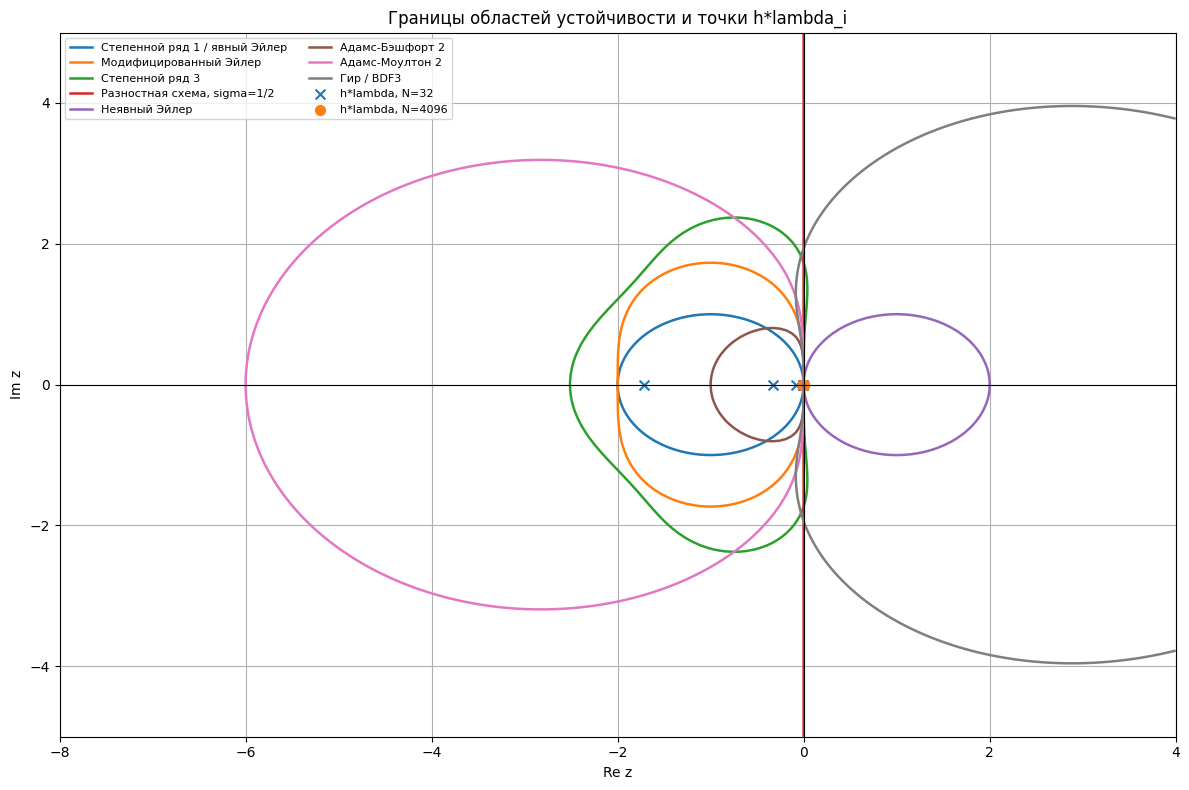

In [30]:
def plot_stability_regions(selected_methods, xlim=(-8, 4), ylim=(-5, 5), points=170):
    xs = np.linspace(xlim[0], xlim[1], points)
    ys = np.linspace(ylim[0], ylim[1], points)
    X, Y = np.meshgrid(xs, ys)
    Z = X + 1j * Y

    plt.figure(figsize=(12, 8))
    cmap = plt.get_cmap("tab10")

    for method_idx, method in enumerate(selected_methods):
        kind = methods_meta[method]["stability"]
        color = cmap(method_idx % 10)

        M = np.empty_like(X, dtype=float)
        for i in range(points):
            for j in range(points):
                M[i, j] = stability_measure(kind, Z[i, j])

        plt.contour(X, Y, M, levels=[1.0], colors=[color], linewidths=1.8)
        plt.plot([], [], color=color, linewidth=1.8, label=methods_meta[method]["title"])

    for N, marker, label in [
        (min(N_values), "x", f"h*lambda, N={min(N_values)}"),
        (max(N_values), "o", f"h*lambda, N={max(N_values)}"),
    ]:
        h = (b - a) / N
        points_lambda = h * eig0
        plt.scatter(
            points_lambda.real,
            points_lambda.imag,
            marker=marker,
            s=50,
            label=label,
        )

    plt.axhline(0, color="black", linewidth=0.8)
    plt.axvline(0, color="black", linewidth=0.8)
    plt.xlabel("Re z")
    plt.ylabel("Im z")
    plt.title("Границы областей устойчивости и точки h*lambda_i")
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()


plot_stability_regions([
    "ps1",
    "modified_euler",
    "ps3",
    "diff_sigma_05",
    "implicit_euler",
    "adams_explicit_2",
    "adams_implicit_2",
    "gear_3",
])

### Динамика решения

Построим компоненты эталонного решения. На графике хорошо видно, почему задача жесткая: часть компонент быстро затухает, а часть меняется на значительно более медленном масштабе времени.


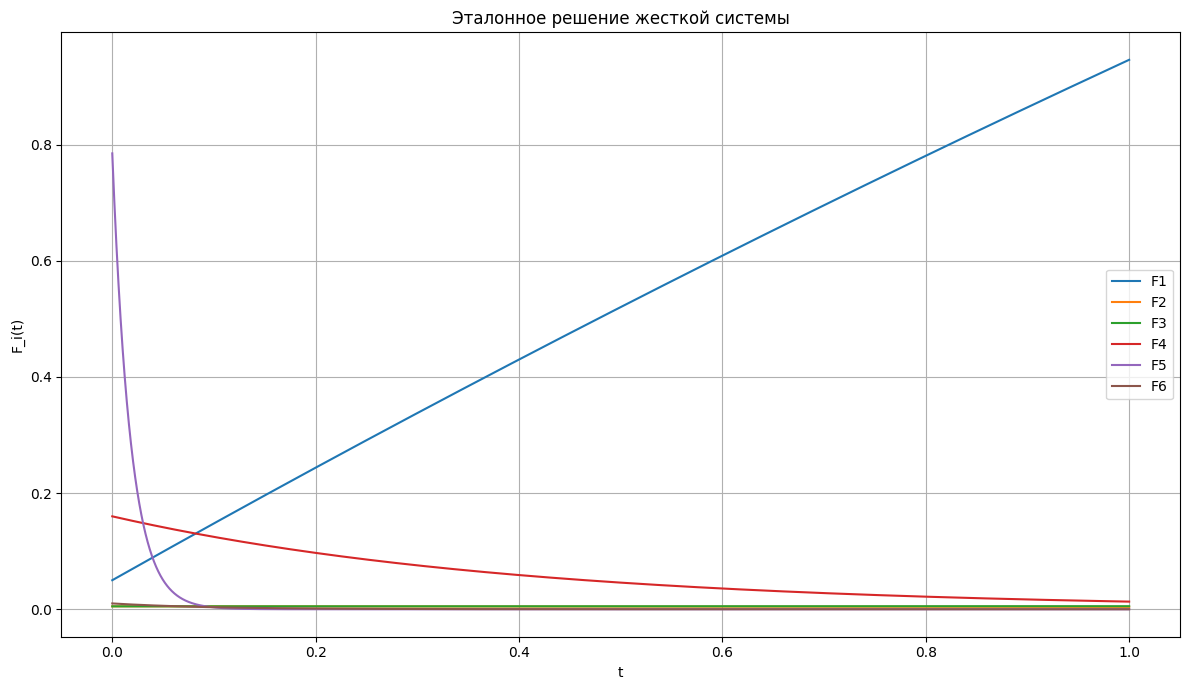

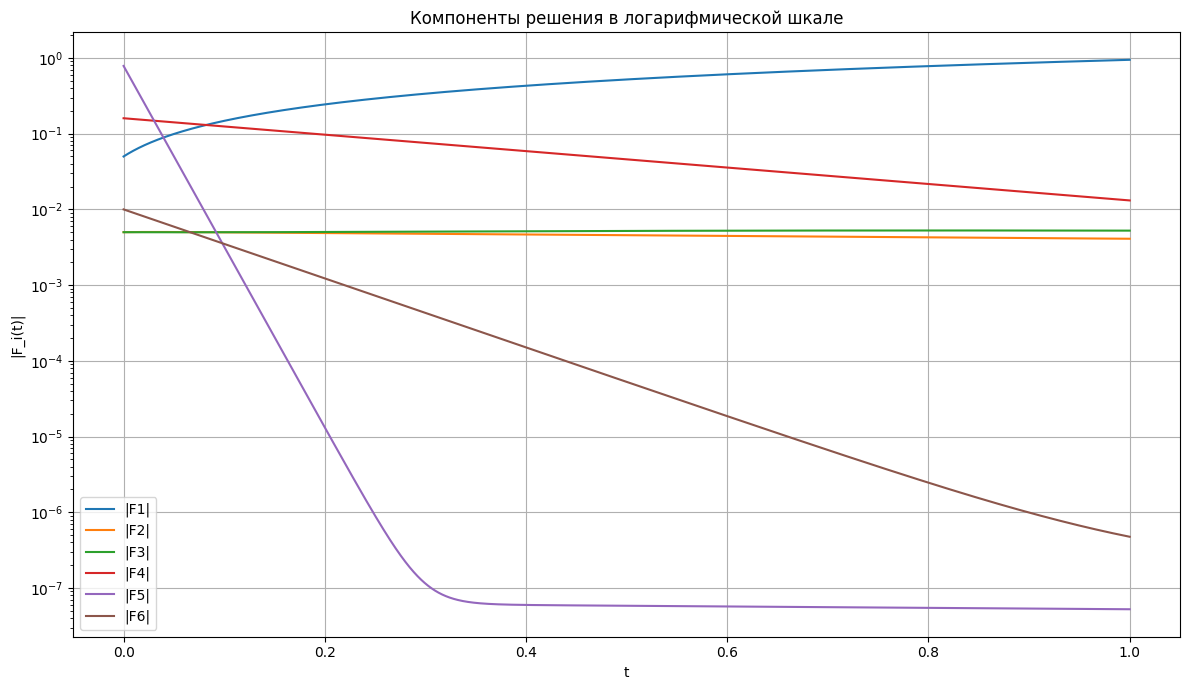

In [31]:
ref_matrix = np.vstack(ref_values)
plt.figure(figsize=(12, 7))
for i in range(6):
    plt.plot(ref_domain, ref_matrix[:, i], label=f"F{i + 1}")

plt.xlabel("t")
plt.ylabel("F_i(t)")
plt.title("Эталонное решение жесткой системы")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
for i in range(6):
    plt.semilogy(ref_domain, np.maximum(np.abs(ref_matrix[:, i]), 1e-16), label=f"|F{i + 1}|")

plt.xlabel("t")
plt.ylabel("|F_i(t)|")
plt.title("Компоненты решения в логарифмической шкале")
plt.legend()
plt.tight_layout()
plt.show()


### Итоговое сравнение

Соберем финальную таблицу по самой мелкой из рабочих сеток. Оптимальный метод будем выбирать по совокупности признаков: малая погрешность, устойчивость, отсутствие срывов Ньютона и разумное время счета.


In [32]:
N_final = max(N_values)
comparison_rows = []

for method in method_order:
    table = method_tables[method]
    row = table[table["N"] == N_final].iloc[0]
    stats = solutions[method][N_final]["stats"]
    stab = stability_df[stability_df["method"] == method].iloc[0]

    comparison_rows.append({
        "method": method,
        "title": methods_meta[method]["title"],
        "order_theory": methods_meta[method]["order"],
        "eps_ref": row["eps_ref"],
        "eps_runge": row["eps_runge"],
        "p_ref_last": row["p_ref"],
        "time_sec": row["time_sec"],
        "newton_iterations": stats["newton_iterations"],
        "newton_failed": stats["newton_failed"],
        "failed": stats["failed"],
        "rough_h_limit": stab["rough_h_limit"],
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df["stable_for_h_final"] = comparison_df["rough_h_limit"].apply(lambda x: True if not np.isfinite(x) else ((b - a) / N_final <= x))
comparison_df["efficiency_score"] = comparison_df["eps_ref"] * np.maximum(comparison_df["time_sec"], 1e-12)
comparison_df = comparison_df.sort_values(["failed", "eps_ref", "time_sec"])

display(comparison_df)

valid = comparison_df[(~comparison_df["failed"]) & np.isfinite(comparison_df["eps_ref"])]
accuracy_winner = valid.iloc[0]
efficient_winner = valid.sort_values("efficiency_score").iloc[0]

print("Минимальная ошибка:", accuracy_winner["title"], "eps =", accuracy_winner["eps_ref"])
print("Лучший баланс ошибка*время:", efficient_winner["title"], "score =", efficient_winner["efficiency_score"])


,method,title,order_theory,eps_ref,eps_runge,p_ref_last,time_sec,newton_iterations,newton_failed,failed,rough_h_limit,stable_for_h_final,efficiency_score
11,adams_pc,Адамс-Бэшфорт-Моултон 4,4,3.121285e-09,3.007992e-09,3.948124,0.352848,189,0,False,0.054545,True,1.101341e-09
10,adams_implicit_2,Адамс-Моултон 2,3,2.815770e-08,2.778820e-08,2.983306,0.397613,840,0,False,0.109091,True,1.119588e-08
2,ps3,Степенной ряд 3,3,2.979188e-08,2.981663e-08,3.001048,2.018337,0,0,False,0.045455,True,6.013006e-08
12,gear_3,Гир / BDF3,3,1.704823e-07,1.664204e-07,2.969497,1.267992,4094,0,False,inf,True,2.161702e-07
7,diff_sigma_05,"Разностная схема, sigma=1/2",2,4.339435e-06,4.339434e-06,2.000000,1.416578,4096,0,False,inf,True,6.147146e-06
1,ps2,Степенной ряд 2,2,8.765674e-06,8.884961e-06,2.014650,0.680655,0,0,False,0.036364,True,5.966401e-06
4,modified_euler,Модифицированный Эйлер,2,8.765674e-06,8.884961e-06,2.014650,0.153450,0,0,False,0.036364,True,1.345094e-06
9,adams_explicit_2,Адамс-Бэшфорт 2,2,2.157772e-05,2.142096e-05,1.992116,0.116725,0,0,False,0.018182,True,2.518651e-06
3,implicit_euler,Неявный Эйлер,1,1.928088e-03,1.906817e-03,0.991934,1.003277,4096,0,False,inf,True,1.934406e-03
8,diff_sigma_1,"Разностная схема, sigma=1",1,1.928088e-03,1.906817e-03,0.991934,1.171370,4096,0,False,inf,True,2.258504e-03


Минимальная ошибка: Адамс-Бэшфорт-Моултон 4 eps = 3.1212854523232636e-09
Лучший баланс ошибка*время: Адамс-Бэшфорт-Моултон 4 score = 1.101340889923177e-09


### Вывод

Система является жесткой: уже в начальной точке собственные значения матрицы Якоби имеют сильно различающиеся отрицательные действительные части, а число жесткости получается больше 100. Поэтому явные методы приходится ограничивать шагом из условий устойчивости. Это видно и по расчетам: на грубых сетках явные методы и центральные разности ведут себя заметно хуже, чем неявные схемы.

Разностная схема с весом $\sigma=\frac12$ и неявные методы хорошо проходят проверку устойчивости. Метод Гира/BDF3 оказывается наиболее естественным кандидатом для этой задачи: он построен именно для жестких систем, допускает существенно более крупный шаг по устойчивости и дает хорошее соотношение точности и надежности. Если требуется максимальная простота реализации, можно выбрать неявный Эйлер, но он имеет только первый порядок. Если требуется более высокая точность при сохранении устойчивости, лучше выбирать метод Гира или неявные методы Адамса.
